In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express

companies = pd.read_csv("unicorn.csv")
companies.head(10)
companies.shape


(1074, 10)

In [6]:
np.mean(companies['Year Founded'])

np.float64(2012.8957169459964)

In [7]:
np.std(companies['Year Founded'])

np.float64(5.695919698215646)

In [11]:
companies['Year Founded'].min()

np.int64(1919)

In [12]:
print('Range is',companies['Year Founded'].max() - companies['Year Founded'].min())

Range is 102


In [15]:
s = companies['Year Founded']
s.describe()

count    1074.000000
mean     2012.895717
std         5.698573
min      1919.000000
25%      2011.000000
50%      2014.000000
75%      2016.000000
max      2021.000000
Name: Year Founded, dtype: float64

In [21]:
companies['Date Joined'] = pd.to_datetime(companies['Date Joined'], format='%m/%d/%y')
companies['Year Joined'] = companies['Date Joined'].dt.year

In [51]:
companies.head(3)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018


In [88]:
def str_to_num(x):
    x = int(x.strip('$B'))
    return x
companies['valuation_num'] = companies['Valuation'].apply(str_to_num)

In [89]:
companies.head(5)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,180
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,100
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018,100
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014,95
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011,46


In [90]:
df_null = pd.isnull(companies)
df_null.shape
companies.shape

(1074, 12)

In [91]:
companies.shape

(1074, 12)

In [92]:
companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   str           
 1   Valuation         1074 non-null   str           
 2   Date Joined       1074 non-null   datetime64[us]
 3   Industry          1074 non-null   str           
 4   City              1058 non-null   str           
 5   Country/Region    1074 non-null   str           
 6   Continent         1074 non-null   str           
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   str           
 9   Select Investors  1073 non-null   str           
 10  Year Joined       1074 non-null   int32         
 11  valuation_num     1074 non-null   int64         
dtypes: datetime64[us](1), int32(1), int64(2), str(8)
memory usage: 96.6 KB


In [93]:
companies.isna()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1069,False,False,False,False,False,False,False,False,False,False,False,False
1070,False,False,False,False,False,False,False,False,False,False,False,False
1071,False,False,False,False,False,False,False,False,False,False,False,False
1072,False,False,False,False,False,False,False,False,False,False,False,False


In [95]:
missing_values = companies.isnull().sum()
missing_values.head(12)

Company              0
Valuation            0
Date Joined          0
Industry             0
City                16
Country/Region       0
Continent            0
Year Founded         0
Funding              0
Select Investors     1
Year Joined          0
valuation_num        0
dtype: int64

In [96]:
missing_values1 = companies.isna()

In [97]:
missing_values1.head(12)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False


In [98]:
mask = companies.isna()

In [99]:
mask = mask.any(axis=1)

In [100]:
mask.head(12)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool

In [102]:
print(companies[mask])

                         Company Valuation Date Joined  \
12                           FTX      $32B  2021-07-20   
170                    HyalRoute       $4B  2020-05-26   
242                       Moglix       $3B  2021-05-17   
251                         Trax       $3B  2019-07-22   
325                  Amber Group       $3B  2021-06-21   
382                    Ninja Van       $2B  2021-09-27   
541   Advance Intelligence Group       $2B  2021-09-23   
629             LinkSure Network       $1B  2015-01-01   
811                    Carousell       $1B  2021-09-15   
848                   Matrixport       $1B  2021-06-01   
880                     bolttech       $1B  2021-07-01   
889                        Carro       $1B  2021-06-14   
893                        Cider       $1B  2021-09-02   
980                         NIUM       $1B  2021-07-13   
986                          ONE       $1B  2021-12-08   
994                      PatSnap       $1B  2021-03-16   
1061          

In [104]:
count_total = companies.size

In [105]:
print(type(count_total))

<class 'int'>


In [106]:
print(count_total)

12888


In [107]:
df_clean = companies.dropna()

In [108]:
count_dropna_rows = df_clean.size

In [109]:
print(f"Antal værdier efter dropna: {count_dropna_rows}")

Antal værdier efter dropna: 12684


In [110]:
df_clean_cols = companies.dropna(axis=1)

In [111]:
count_dropna_columns = df_clean_cols.size

In [112]:
print(f"Antal celler efter at have fjernet kolonner med missing values: {count_dropna_columns}")

Antal celler efter at have fjernet kolonner med missing values: 10740


In [113]:
percent_removed_cols = ((count_total - count_dropna_columns) / count_total) * 100
print(f"Procentdel af værdier fjernet ved at droppe kolonner: {percent_removed_cols:.2f}%")

Procentdel af værdier fjernet ved at droppe kolonner: 16.67%


In [115]:
percent_removed_rows = ((count_total - count_dropna_rows) / count_total) * 100
print(f"Procentdel af værdier fjernet ved at droppe rækker: {percent_removed_rows:.2f}%")

Procentdel af værdier fjernet ved at droppe rækker: 1.58%


In [118]:
df_companies_backfill = companies.fillna('backfill')

In [119]:
df_companies_backfill.head(5)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,180
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,100
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018,100
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014,95
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011,46


In [120]:
companies.loc[(companies['City'].isna()) & (companies['Country/Region'] == 'Singapore'), 'City'] = 'Singapore'

In [121]:
companies.loc[(companies['City'].isna()) & (companies['Country/Region'] == 'Hong Kong'), 'City'] = 'Hong Kong'

In [122]:
mask = companies.isna()

In [123]:
mask = mask.any(axis=1)

In [124]:
mask.head(12)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool

In [125]:
print(companies[mask])

              Company Valuation Date Joined                     Industry  \
12                FTX      $32B  2021-07-20                      Fintech   
629  LinkSure Network       $1B  2015-01-01  Mobile & telecommunications   

         City Country/Region      Continent  Year Founded Funding  \
12        NaN        Bahamas  North America          2018     $2B   
629  Shanghai          China           Asia          2013    $52M   

                           Select Investors  Year Joined  valuation_num  
12   Sequoia Capital, Thoma Bravo, Softbank         2021             32  
629                                     NaN         2015              1  


In [129]:
df_invest = companies[(companies['Industry'] == 'Artificial intelligence') & (companies['City'] == 'London')]

In [130]:
df_invest.head(5)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
873,BenevolentAI,$1B,2015-06-02,Artificial intelligence,London,United Kingdom,Europe,2013,$292M,Woodford Investment Management,2015,1
1046,Tractable,$1B,2021-06-16,Artificial intelligence,London,United Kingdom,Europe,2014,$120M,"Insight Partners, Ignition Partners, Georgian ...",2021,1


In [131]:
df_invest = companies[(companies['Industry'] == 'Artificial Intelligence') & (companies['City'] == 'London')]

In [132]:
df_invest.head(5)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num


In [133]:
df_invest = companies[(companies['Industry'] == 'Artificial intelligence') & (companies['City'] == 'London')]

In [134]:
df_invest.head(5)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
873,BenevolentAI,$1B,2015-06-02,Artificial intelligence,London,United Kingdom,Europe,2013,$292M,Woodford Investment Management,2015,1
1046,Tractable,$1B,2021-06-16,Artificial intelligence,London,United Kingdom,Europe,2014,$120M,"Insight Partners, Ignition Partners, Georgian ...",2021,1


In [135]:
national_valuations = companies.groupby('Country/Region')['valuation_num'].sum().sort_values(ascending=False)

In [137]:
national_valuations.info()

<class 'pandas.Series'>
Index: 46 entries, United States to Italy
Series name: valuation_num
Non-Null Count  Dtype
--------------  -----
46 non-null     int64
dtypes: int64(1)
memory usage: 736.0+ bytes


In [138]:
national_valuations.head(5)

Country/Region
United States     1933
China              696
India              196
United Kingdom     195
Germany             72
Name: valuation_num, dtype: int64

In [139]:
national_valuations.head(20)

Country/Region
United States     1933
China              696
India              196
United Kingdom     195
Germany             72
Sweden              63
Australia           56
France              55
Canada              49
South Korea         41
Israel              39
Brazil              37
Bahamas             32
Indonesia           28
Singapore           21
Netherlands         19
Hong Kong           18
Turkey              16
Mexico              16
Estonia             13
Name: valuation_num, dtype: int64

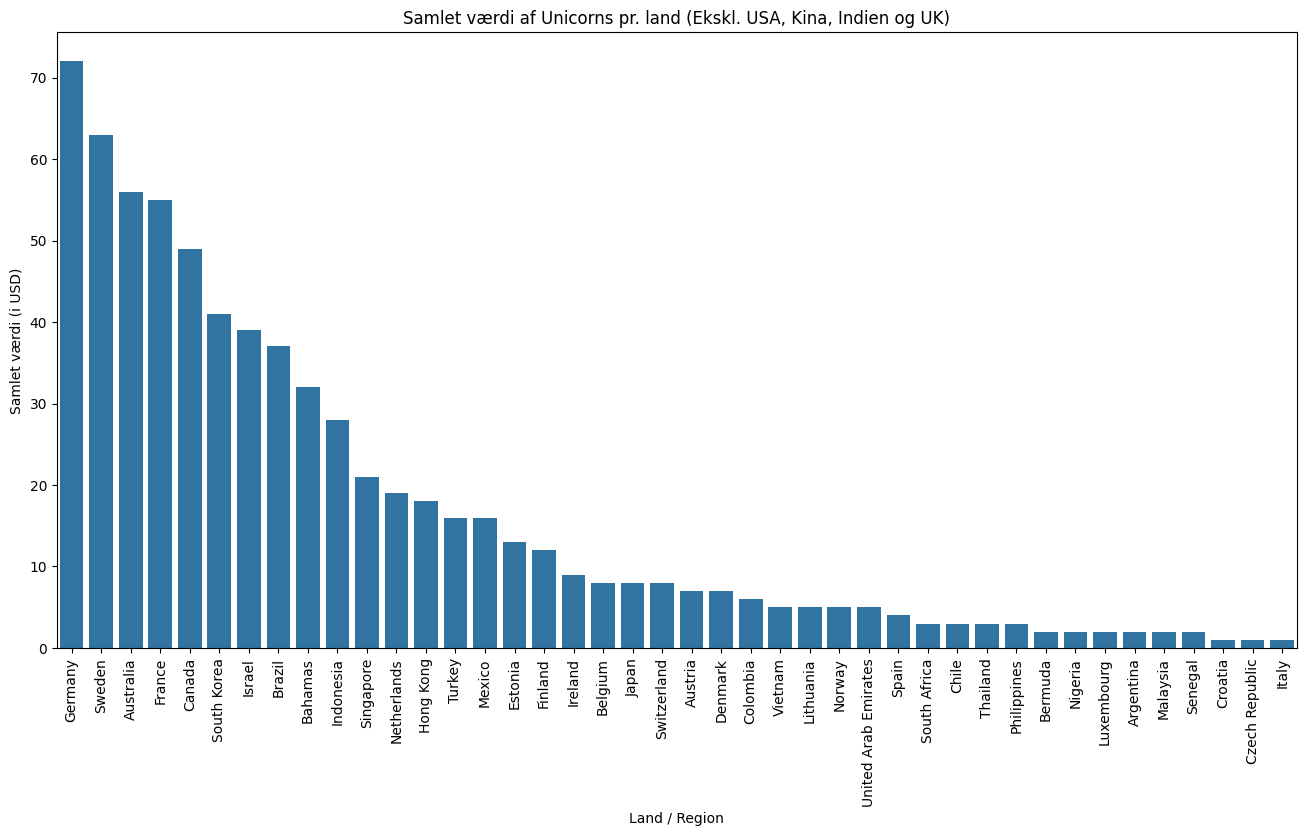

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definer de lande der skal fjernes (The Big 4)
big_4 = ['United States', 'China', 'India', 'United Kingdom']

# 2. Fjern dem ved hjælp af .drop() og gem i den nye variabel
national_valuations_no_big4 = national_valuations.drop(labels=big_4)

# 3. Opsætning af plottet
plt.figure(figsize=(16, 8)) # Gør figuren bred, så alle lande kan stå der

# 4. Lav barplottet
sns.barplot(
    x=national_valuations_no_big4.index,
    y=national_valuations_no_big4.values
)

# 5. Formatering for at gøre det læsbart
plt.xticks(rotation=90) # Roter landenavnene 90 grader
plt.title('Samlet værdi af Unicorns pr. land (Ekskl. USA, Kina, Indien og UK)')
plt.ylabel('Samlet værdi (i USD)')
plt.xlabel('Land / Region')

# Vis plottet
plt.show()